CELL 1 — Import Library

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

CELL 2 — Load Dataset & Rename Kolom

In [2]:
df = pd.read_csv("HTRU_2.csv", header=None)

df.columns = [
    "mean_profile",
    "std_profile",
    "skewness_profile",
    "kurtosis_profile",
    "mean_dm_snr",
    "std_dm_snr",
    "skewness_dm_snr",
    "kurtosis_dm_snr",
    "class"
]

df.head()

,mean_profile,std_profile,skewness_profile,kurtosis_profile,mean_dm_snr,std_dm_snr,skewness_dm_snr,kurtosis_dm_snr,class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


CELL 3 — Hapus Kolom Label 

In [3]:
# Dataset untuk clustering (tanpa label)
X = df.drop(columns=["class"])

X.shape

(17898, 8)

CELL 4 — Standarisasi Fitur

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 1.14931702,  1.33483164, -0.66956953, -0.400459  , -0.31944026,
        -0.37062547, -0.07279778, -0.28743812],
       [-0.3341682 ,  1.80226533, -0.01178476, -0.37053549, -0.37110188,
        -0.5889241 ,  0.50442694,  0.21158145],
       [-0.31437216, -1.05332222, -0.14523256, -0.11659286, -0.32210703,
        -0.23532816, -0.12599609, -0.39137346],
       [ 1.0006944 ,  1.55325441, -0.51340862, -0.39017809, -0.3044042 ,
        -0.27566649, -0.31226539, -0.4813003 ],
       [-0.87140244, -0.85887881,  0.11560871, -0.10486616, -0.38801036,
        -0.76311112,  1.32402614,  1.38679399]])

CELL 5 — Elbow Method

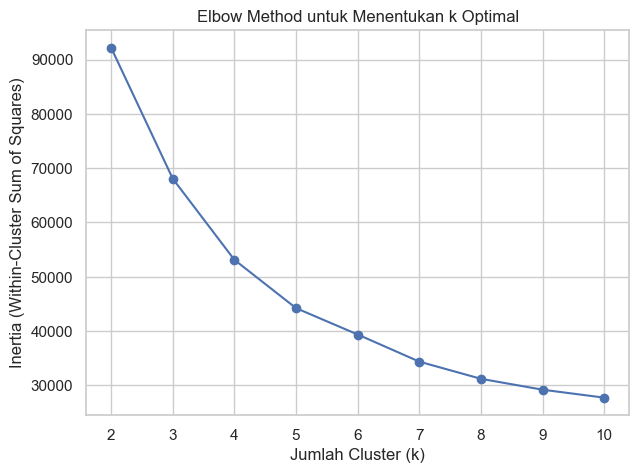

In [5]:
inertias = []
K_range = range(2, 11)  # k = 2 sampai 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method untuk Menentukan k Optimal")
plt.xticks(K_range)
plt.show()

CELL 6 — Silhouette Score untuk Beberapa Nilai k

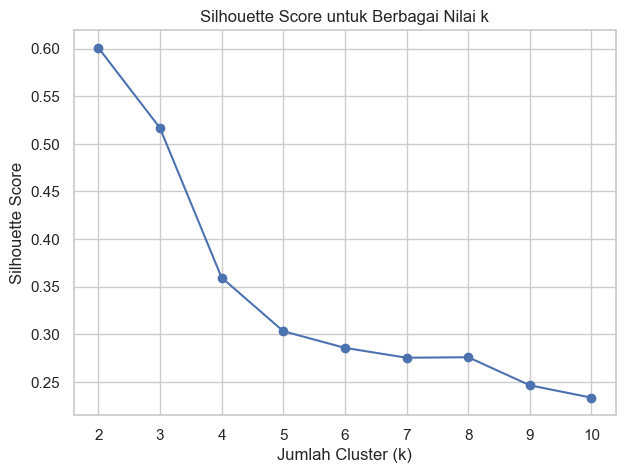

k = 2: Silhouette Score = 0.6010
k = 3: Silhouette Score = 0.5168
k = 4: Silhouette Score = 0.3596
k = 5: Silhouette Score = 0.3033
k = 6: Silhouette Score = 0.2858
k = 7: Silhouette Score = 0.2754
k = 8: Silhouette Score = 0.2760
k = 9: Silhouette Score = 0.2465
k = 10: Silhouette Score = 0.2335


In [6]:
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(7,5))
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score untuk Berbagai Nilai k")
plt.xticks(K_range)
plt.show()

for k, sil in zip(K_range, sil_scores):
    print(f"k = {k}: Silhouette Score = {sil:.4f}")

CELL 7 — Training K-Means dengan k Terpilih

In [7]:
best_k = 2  # ganti sesuai hasil analisis kamu

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Simpan label cluster ke dataframe untuk analisis
df_clusters = df.copy()
df_clusters["cluster"] = cluster_labels

df_clusters.head()

,mean_profile,std_profile,skewness_profile,kurtosis_profile,mean_dm_snr,std_dm_snr,skewness_dm_snr,kurtosis_dm_snr,class,cluster
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0,0


CELL 8 — Visualisasi Cluster dengan PCA 2D

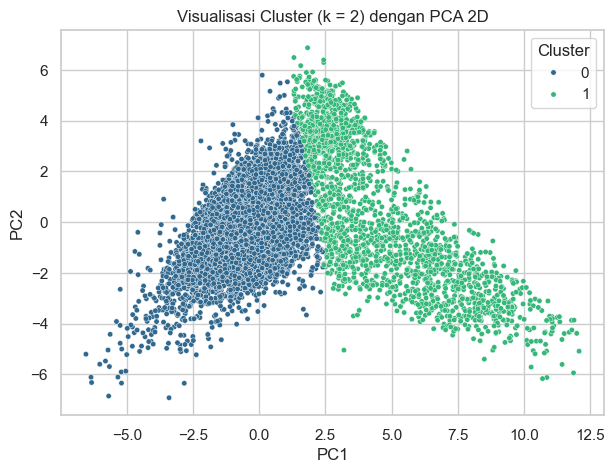

In [8]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=cluster_labels,
    palette="viridis",
    s=15
)
plt.title(f"Visualisasi Cluster (k = {best_k}) dengan PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

CELL 9 — Analisis Sederhana Setiap Cluster (Rata-rata Fitur)

In [9]:
cluster_summary = df_clusters.groupby("cluster").mean(numeric_only=True)
cluster_summary

,mean_profile,std_profile,skewness_profile,kurtosis_profile,mean_dm_snr,std_dm_snr,skewness_dm_snr,kurtosis_dm_snr,class
cluster,,,,,,,,,
0,115.870374,47.064924,0.228115,0.417639,4.110780,20.714607,9.254462,118.161425,0.022602
1,74.229442,42.584837,2.399014,12.175557,78.029079,69.496499,0.988650,2.517950,0.622147


CELL 10 — (Opsional) Gabungkan Cluster dengan Label Asli (Class)

In [10]:
crosstab = pd.crosstab(df_clusters["cluster"], df_clusters["class"], 
                       rownames=["Cluster"], colnames=["Class"])
crosstab

Class,0,1
Cluster,,
0,15481,358
1,778,1281
